# Travel Package Purchase Prediction using Machine Learning

## Business Problem
The objective of this project is to build and compare multiple machine learning classification models to predict whether a customer will purchase a travel package.

### Objectives
- Perform Exploratory Data Analysis (EDA)
- Handle missing values and engineer useful features
- Build an end-to-end preprocessing pipeline
- Train baseline models
- Perform hyperparameter tuning
- Evaluate models using multiple metrics
- Explain model predictions and save the best model

---
**Author:** Milind Chavan


# Table of Contents
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Missing Value Analysis
5. Data Cleaning & Feature Engineering
6. Train-Test Split
7. Data Preprocessing
8. Baseline Models
9. Hyperparameter Tuning
10. Model Evaluation
11. Explainability
12. Save Best Model
13. Conclusion


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
print(df.dtypes)

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOfPitch             float64
Occupation                      str
Gender                          str
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched                  str
PreferredPropertyStar       float64
MaritalStatus                   str
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                     str
MonthlyIncome               float64
dtype: object


In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [6]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [7]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [8]:
df['Gender'] = df['Gender'].replace('Fe Male','Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')

In [9]:
features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]
print("No of features with nan values :",len(features_with_na))

No of features with nan values : 8


In [10]:
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), "% missing values")

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [11]:
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing Null values
1. Impute Median value for Age column
2. Impute Mode for Type of Contract
3. Impute Median for Duration of Pitch
4. Impute Mode for NumberofFollowup as it is Discrete feature
5. Impute Mode for PreferredPropertyStar
6. Impute Median for NumberofTrips
7. Impute Mode for NumberOfChildrenVisiting
8. Impute Median for MonthlyIncome

In [12]:
# Age
df["Age"] = df["Age"].fillna(df["Age"].median())

# TypeofContact
df["TypeofContact"] = df["TypeofContact"].fillna(df["TypeofContact"].mode()[0])

# DurationOfPitch
df["DurationOfPitch"] = df["DurationOfPitch"].fillna(df["DurationOfPitch"].median())

# NumberOfFollowups
df["NumberOfFollowups"] = df["NumberOfFollowups"].fillna(df["NumberOfFollowups"].mode()[0])

# PreferredPropertyStar
df["PreferredPropertyStar"] = df["PreferredPropertyStar"].fillna(df["PreferredPropertyStar"].mode()[0])

# NumberOfTrips
df["NumberOfTrips"] = df["NumberOfTrips"].fillna(df["NumberOfTrips"].median())

# NumberOfChildrenVisiting
df["NumberOfChildrenVisiting"] = df["NumberOfChildrenVisiting"].fillna(df["NumberOfChildrenVisiting"].mode()[0])

# MonthlyIncome
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

In [13]:
df.head()
print(df.isnull().sum())

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64


In [14]:
df.drop('CustomerID', inplace=True, axis=1)


In [15]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Feature Engineering

In [16]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],inplace=True)

In [17]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [18]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'str']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 12


In [19]:
## get all the categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'str']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 6


In [20]:
## get all the discrete features
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <=25 ]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 9


In [21]:
## get all the continuos features
continuos_feature = [feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuos_feature))

Num of Continuous Features : 3


In [22]:
# Split the dataset before preprocessing to prevent data leakage.
# The test data must remain completely unseen during training.
from sklearn.model_selection import train_test_split
X = df.drop(['ProdTaken'],axis=1)
y = df['ProdTaken']

cat_features = X.select_dtypes(include="object").columns

num_features = X.select_dtypes(exclude="object").columns

In [23]:
# Split the dataset before preprocessing to prevent data leakage.
# The test data must remain completely unseen during training.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape , X_test.shape

((3910, 17), (978, 17))

In [24]:
# Apply different preprocessing to numerical and categorical features.
# This keeps preprocessing reproducible inside the ML pipeline.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first",handle_unknown='ignore'), cat_features),
    ("num", StandardScaler(), num_features)
])

In [25]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   str    
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   str    
 5   Gender                  4888 non-null   str    
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   str    
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   str    
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   str    
 15

In [26]:
# Combine preprocessing and model into a single reusable workflow.
# This avoids data leakage during cross-validation.
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Models
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),

    "Gradient Boost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),

    "AdaBoost" : Pipeline([
        ("preprocessor",preprocessor),
        ("model", AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),random_state=42))
    ]),

    "XGBoost" : Pipeline([
        ('preprocessor',preprocessor),
        ('model',XGBClassifier(random_state = 42))
    ])
}

# Train and Evaluate Models
for model_name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ==========================
    # Training Metrics
    # ==========================
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    train_roc_auc = roc_auc_score(y_train, y_train_pred)

    # ==========================
    # Testing Metrics
    # ==========================
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    test_roc_auc = roc_auc_score(y_test, y_test_pred)

    # ==========================
    # Print Results
    # ==========================
    print(f"Model: {model_name}")

    print("\nTraining Performance")
    print(f"Accuracy      : {train_accuracy:.4f}")
    print(f"Precision     : {train_precision:.4f}")
    print(f"Recall        : {train_recall:.4f}")
    print(f"F1 Score      : {train_f1:.4f}")
    print(f"ROC AUC Score : {train_roc_auc:.4f}")

    print("-" * 40)

    print("Testing Performance")
    print(f"Accuracy      : {test_accuracy:.4f}")
    print(f"Precision     : {test_precision:.4f}")
    print(f"Recall        : {test_recall:.4f}")
    print(f"F1 Score      : {test_f1:.4f}")
    print(f"ROC AUC Score : {test_roc_auc:.4f}")

    print("=" * 60)
    print()

Model: Logistic Regression

Training Performance
Accuracy      : 0.8460
Precision     : 0.7016
Recall        : 0.3032
F1 Score      : 0.8202
ROC AUC Score : 0.6368
----------------------------------------
Testing Performance
Accuracy      : 0.8364
Precision     : 0.6914
Recall        : 0.2932
F1 Score      : 0.8087
ROC AUC Score : 0.6307

Model: Decision Tree

Training Performance
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000
ROC AUC Score : 1.0000
----------------------------------------
Testing Performance
Accuracy      : 0.9243
Precision     : 0.8232
Recall        : 0.7801
F1 Score      : 0.9236
ROC AUC Score : 0.8697

Model: Random Forest

Training Performance
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000
ROC AUC Score : 1.0000
----------------------------------------
Testing Performance
Accuracy      : 0.9294
Precision     : 0.9692
Recall        : 0.6597
F1 Score      : 0.9241
ROC AUC Score

In [27]:
# RandomizedSearchCV efficiently searches the hyperparameter space.
# It is faster than GridSearchCV for larger search spaces.
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier

In [28]:
# Combine preprocessing and model into a single reusable workflow.
# This avoids data leakage during cross-validation.

# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Decision Tree Pipeline
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# AdaBoost Pipeline
ada_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),random_state=42))
])

#XGBoost Pipeline
Xgb_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(random_state=42))
])

In [29]:
lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

dt_params = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"],
    "model__bootstrap": [True, False]
}

gb_params = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
    "model__max_features": [None, "sqrt", "log2"],
    "model__criterion": ["friedman_mse", "squared_error"],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

ada_params = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__estimator__max_depth": [1, 2, 3],
    "model__learning_rate":[0.01,0.25,0.50,0.75,1.0,1.25,1.50]
}

xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7, 10],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}

In [30]:
randomcv_models = [
    ("Logistic Regression", lr_pipeline, lr_params),
    ("Decision Tree", dt_pipeline, dt_params),
    ("Random Forest", rf_pipeline, rf_params),
    ("Gradient Boosting", gb_pipeline, gb_params),
    ('AdaBoost',ada_pipeline,ada_params),
    ('XgBoost',Xgb_pipeline,xgb_params)
]

In [ ]:
# RandomizedSearchCV efficiently searches the hyperparameter space.
# It is faster than GridSearchCV for larger search spaces.
from sklearn.model_selection import StratifiedKFold
model_param = {}

cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
        )

for name, model, params in randomcv_models:

    print("=" * 70)
    print(f"Training {name}")
    print("=" * 70)

    
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,
        cv=cv,
        scoring="roc_auc",
        random_state=42,
        verbose=2,
        n_jobs=-1,
        error_score="raise"
    )

    random.fit(X_train, y_train)

    model_param[name] = {
        "Best Parameters": random.best_params_,
        "Best Score": random.best_score_,
        "Best Estimator": random.best_estimator_
    }

In [32]:
for model_name in model_param:

    print("\n" + "="*80)
    print(f"Best Results for {model_name}")
    print("="*80)

    print("\nBest Cross Validation Score:")
    print(model_param[model_name]["Best Score"])

    print("\nBest Parameters:")
    print(model_param[model_name]["Best Parameters"])


Best Results for Logistic Regression

Best Cross Validation Score:
0.8059655595329774

Best Parameters:
{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 10}

Best Results for Decision Tree

Best Cross Validation Score:
0.8345355487769293

Best Parameters:
{'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 20, 'model__criterion': 'gini'}

Best Results for Random Forest

Best Cross Validation Score:
0.968505002814364

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None, 'model__criterion': 'gini', 'model__bootstrap': False}

Best Results for Gradient Boosting

Best Cross Validation Score:
0.9538679287024285

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__

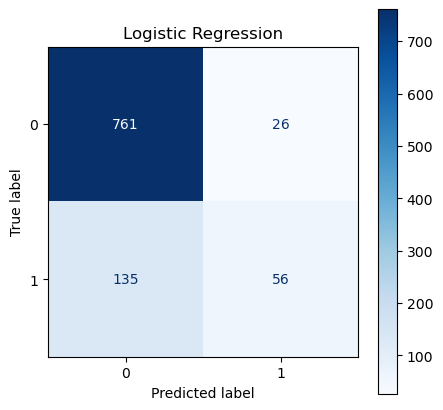

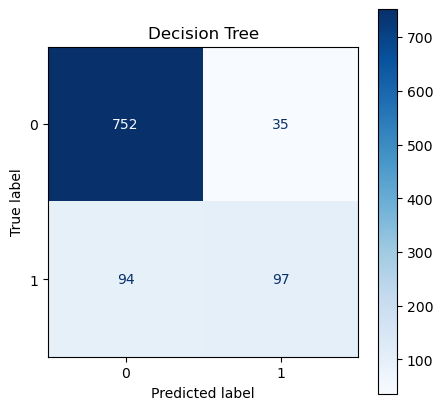

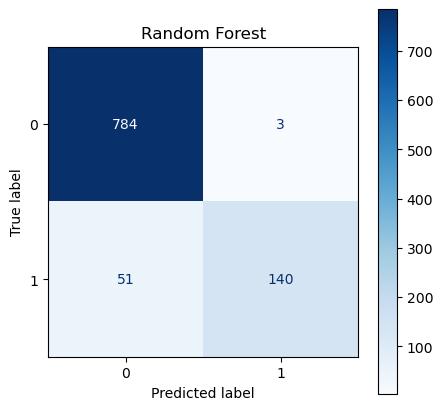

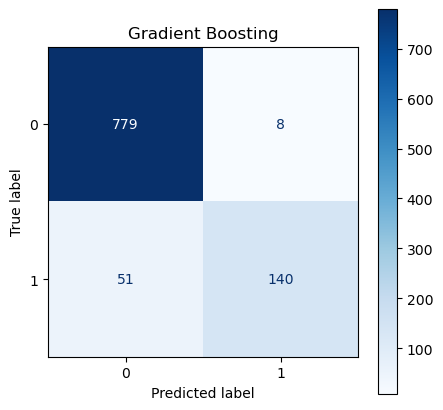

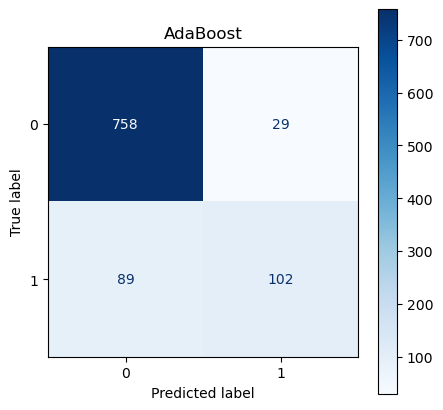

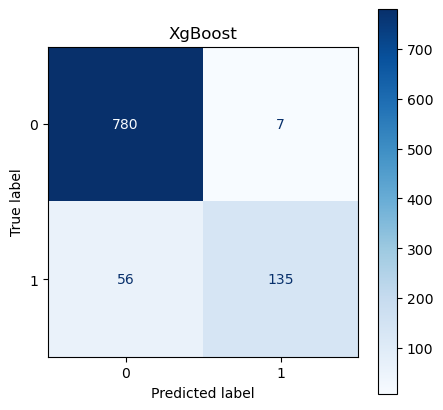

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name in model_param:

    best_model = model_param[model_name]["Best Estimator"]

    fig, ax = plt.subplots(figsize=(5,5))

    ConfusionMatrixDisplay.from_estimator(
        best_model,
        X_test,
        y_test,
        cmap="Blues",
        ax=ax
    )

    plt.title(model_name)

    plt.show()

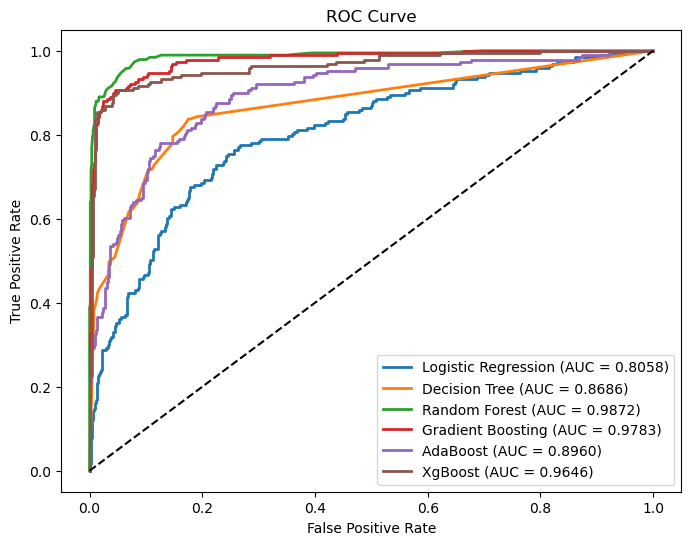

In [34]:
# Plot the ROC Curve to visualize the trade-off between TPR and FPR.
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for model_name in model_param:

    model = model_param[model_name]["Best Estimator"]

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr,
             linewidth=2,
             label=f"{model_name} (AUC = {auc:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

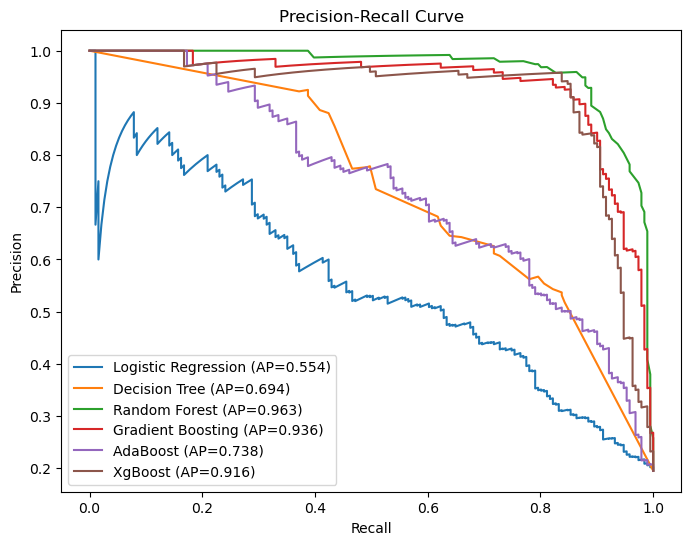

In [35]:
# Plot the Precision-Recall Curve.
# This is especially informative for imbalanced classification problems.
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

plt.figure(figsize=(8,6))

for model_name in model_param:

    model = model_param[model_name]["Best Estimator"]

    y_prob = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [36]:
# Extract feature importance scores from the trained Random Forest model.
import pandas as pd
import matplotlib.pyplot as plt

best_rf = model_param["Random Forest"]["Best Estimator"]

feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_rf.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importance

}).sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

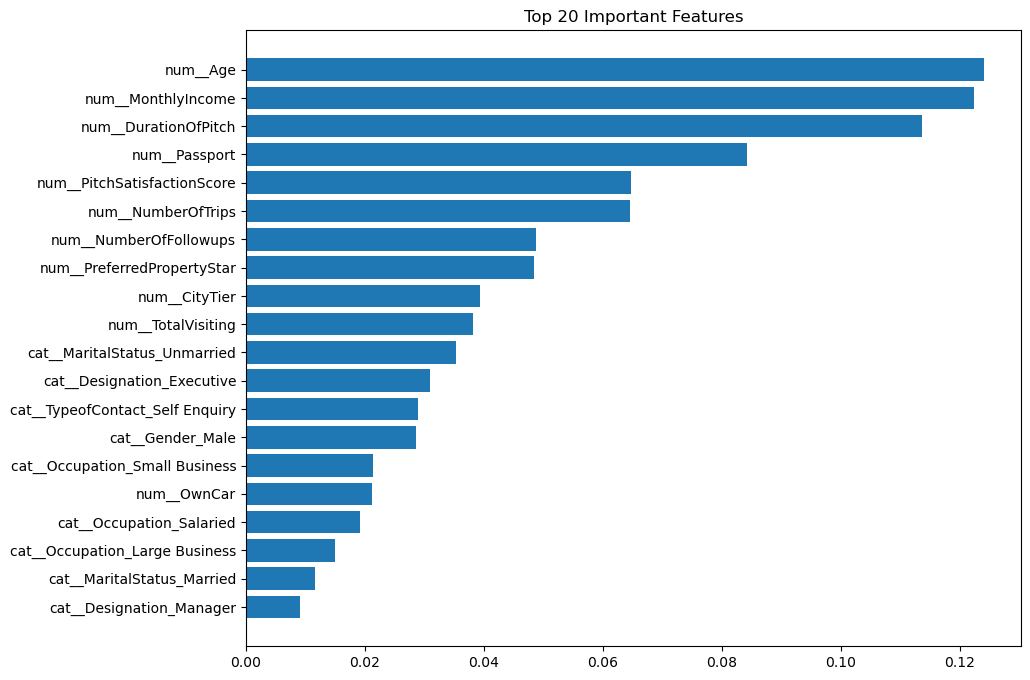

In [37]:
plt.figure(figsize=(10,8))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test):

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Training Accuracy :", accuracy_score(y_train, y_train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, y_test_pred))

    print("Precision :", precision_score(y_test, y_test_pred))
    print("Recall    :", recall_score(y_test, y_test_pred))
    print("F1 Score  :", f1_score(y_test, y_test_pred))
    print("ROC AUC   :", roc_auc_score(y_test, y_test_pred))

In [39]:
for model_name in model_param:

    print("="*70)

    print(model_name)

    print("="*70)

    evaluate_model(
        model_param[model_name]["Best Estimator"],
        X_train,
        y_train,
        X_test,
        y_test
    )

Logistic Regression
Training Accuracy : 0.8465473145780051
Testing Accuracy  : 0.8353783231083844
Precision : 0.6829268292682927
Recall    : 0.2931937172774869
F1 Score  : 0.41025641025641024
ROC AUC   : 0.6300784342423011
Decision Tree
Training Accuracy : 0.9409207161125319
Testing Accuracy  : 0.8680981595092024
Precision : 0.7348484848484849
Recall    : 0.5078534031413613
F1 Score  : 0.6006191950464397
ROC AUC   : 0.7316903610370085
Random Forest
Training Accuracy : 1.0
Testing Accuracy  : 0.9447852760736196
Precision : 0.9790209790209791
Recall    : 0.7329842931937173
F1 Score  : 0.8383233532934131
ROC AUC   : 0.8645861745511153
Gradient Boosting
Training Accuracy : 1.0
Testing Accuracy  : 0.9396728016359919
Precision : 0.9459459459459459
Recall    : 0.7329842931937173
F1 Score  : 0.8259587020648967
ROC AUC   : 0.8614095544748765
AdaBoost
Training Accuracy : 0.9352941176470588
Testing Accuracy  : 0.8793456032719836
Precision : 0.7786259541984732
Recall    : 0.5340314136125655
F1 Sco

In [40]:
results = []

for model_name in model_param:

    model = model_param[model_name]["Best Estimator"]

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(y_test,pred),

        "Precision": precision_score(y_test,pred),

        "Recall": recall_score(y_test,pred),

        "F1": f1_score(y_test,pred),

        "ROC_AUC": roc_auc_score(y_test,prob)

    })

results = pd.DataFrame(results)

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.944785,0.979021,0.732984,0.838323,0.987210
3,Gradient Boosting,0.939673,0.945946,0.732984,0.825959,0.978319
5,XgBoost,0.935583,0.950704,0.706806,0.810811,0.964615
4,AdaBoost,0.879346,0.778626,0.534031,0.633540,0.896013
1,Decision Tree,0.868098,0.734848,0.507853,0.600619,0.868608
0,Logistic Regression,0.835378,0.682927,0.293194,0.410256,0.805784


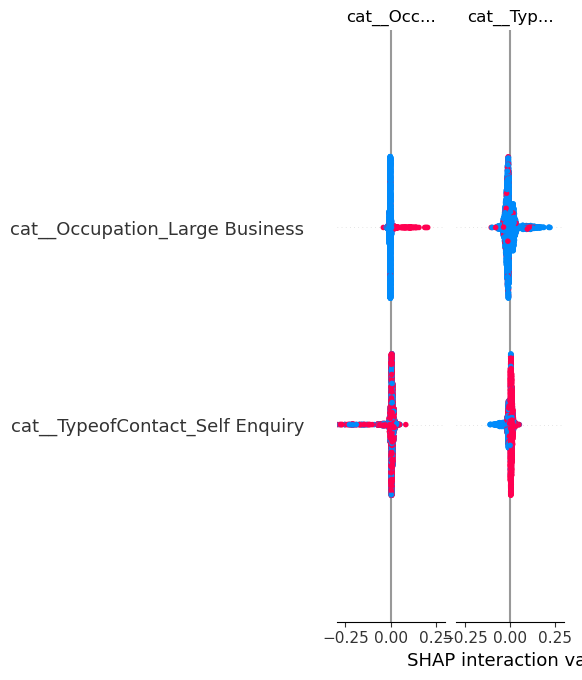

In [41]:
import shap

best_rf = model_param["Random Forest"]["Best Estimator"]

X_train_transformed = best_rf.named_steps[
    "preprocessor"
].transform(X_train)

explainer = shap.TreeExplainer(
    best_rf.named_steps["model"]
)

shap_values = explainer.shap_values(
    X_train_transformed
)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=best_rf.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

# Conclusion

### Summary
- Missing values were handled appropriately.
- Feature engineering improved the dataset.
- Pipelines and ColumnTransformer prevented data leakage.
- Hyperparameter tuning was performed using RandomizedSearchCV with Stratified K-Fold.
- Multiple models were compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC, ROC Curve and Precision-Recall Curve.
- Random Forest achieved the best overall performance.
- The final trained model was saved using joblib for future deployment.

### Future Improvements
- Try XGBoost, LightGBM or CatBoost.
- Perform probability calibration.
- Deploy the model using FastAPI or Flask.
- Monitor model drift after deployment.
